In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Mnist CNN model

In [8]:
#GPU 연결
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
#dataset 정의 및 로더
batch_size = 50
mnist_train = datasets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = datasets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

train_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

test_loader = torch.utils.data.DataLoader(dataset=mnist_test,
                                          batch_size=1000,
                                          shuffle=False)

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.fc = nn.Linear(7 * 7 * 64, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        return x

mnist_model = CNN().to(device)

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)

In [11]:
epochs = 5
total_batch = len(train_loader)

mnist_model.train()
for epoch in range(epochs):
    avg_cost = 0

    for X, Y in train_loader:
        X = X.to(device) 
        Y = Y.to(device) 

        optimizer.zero_grad()
        output = mnist_model(X)
        cost = criterion(output, Y)
        cost.backward()
        optimizer.step()
        
        avg_cost += cost / total_batch

    print('[Epoch: {}] cost = {:.6f}'.format(epoch + 1, avg_cost))

torch.save(mnist_model.state_dict(), "my_model.pth")
print("모델 저장 완료")

[Epoch: 1] cost = 0.161688
[Epoch: 2] cost = 0.052922
[Epoch: 3] cost = 0.037479
[Epoch: 4] cost = 0.029670
[Epoch: 5] cost = 0.022946
모델 저장 완료


In [12]:
print("Evaluating Model...")
mnist_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, Y in test_loader:
        X = X.to(device)
        Y = Y.to(device)

        prediction = mnist_model(X)
        _, predicted_classes = torch.max(prediction.data, 1)
        total += Y.size(0)
        correct += (predicted_classes == Y).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy on MNIST: {accuracy:.2f}%')

Evaluating Model...
Test Accuracy on MNIST: 98.82%


# cifar10 pretrained model

In [13]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

cifar_test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
cifar_test_loader = DataLoader(cifar_test_set, batch_size=128, shuffle=False)

Files already downloaded and verified


In [15]:
class NormalizationLayer(nn.Module):
    def __init__(self):
        super(NormalizationLayer, self).__init__()
        self.mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
        self.std = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1)

    def forward(self, x):
        return (x - self.mean.to(x.device)) / self.std.to(x.device)

# 출처: https://github.com/chenyaofo/pytorch-cifar-models
raw_model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
cifar_model = nn.Sequential(
    NormalizationLayer(),
    raw_model
).to(device)

cifar_model.eval()

Using cache found in C:\Users\USER/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


Sequential(
  (0): NormalizationLayer()
  (1): CifarResNet(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        

In [16]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in cifar_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cifar_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy on CIFAR-10: {accuracy:.2f}%')

Test Accuracy on CIFAR-10: 92.60%


# Attack method

In [17]:
def fgsm_targeted(model, x, target, eps):
    x.requires_grad = True
    outputs = model(x)
    criterion = nn.CrossEntropyLoss()
    loss = criterion(outputs, target)
    model.zero_grad()
    loss.backward()
    x_adv = x - eps * x.grad.data.sign()
    x_adv = torch.clamp(x_adv, 0, 1)
    
    return x_adv.detach()

In [18]:
def fgsm_untargeted(model, x, label, eps):
    x.requires_grad = True
    outputs = model(x)
    criterion = nn.CrossEntropyLoss()
    loss = criterion(outputs, label)
    model.zero_grad()
    loss.backward()
    x_adv = x + eps * x.grad.data.sign()
    x_adv = torch.clamp(x_adv, 0, 1)
    
    return x_adv.detach()

In [19]:
def pgd_targeted(model, x, target, k, eps, eps_step):
    x_ori = x.clone().detach()
    x_adv = x.clone().detach()
    
    for i in range(k):
        x_adv.requires_grad = True
        outputs = model(x_adv)
        
        criterion = nn.CrossEntropyLoss()
        loss = criterion(outputs, target)
        
        model.zero_grad()
        loss.backward()
        
        x_adv = x_adv - eps_step * x_adv.grad.data.sign()
        
        x_adv = torch.max(torch.min(x_adv, x_ori + eps), x_ori - eps)
        
        x_adv = torch.clamp(x_adv, 0, 1).detach()
        
    return x_adv

In [20]:
def pgd_untargeted(model, x, target, k, eps, eps_step):
    x_ori = x.clone().detach()
    x_adv = x.clone().detach()
    
    for i in range(k):
        x_adv.requires_grad = True
        
        outputs = model(x_adv)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(outputs, target)
        
        model.zero_grad()
        loss.backward()
        
        x_adv = x_adv + eps_step * x_adv.grad.data.sign()
        
        x_adv = torch.max(torch.min(x_adv, x_ori + eps), x_ori - eps)
        
        x_adv = torch.clamp(x_adv, 0, 1).detach()
        
    return x_adv

In [21]:
import matplotlib.pyplot as plt
import os

os.makedirs('results', exist_ok=True)


def evaluate_attack(target_model, device, loader, attack_func, attack_name, dataset_name, **kwargs):
    target_model.eval()
    success = 0
    total = 0
    vis_count = 0
    plt.figure(figsize=(10, 8))
    
    sample_limit = 100
    
    for images, labels in loader:
        if total >= sample_limit: break
        
        images, labels = images.to(device), labels.to(device)
        
        outputs = target_model(images)
        _, pre_labels = torch.max(outputs, 1)
        
        if 'targeted' in attack_name.lower():
            targets = (labels + 1) % 10
            adv_images = attack_func(target_model, images, targets, **kwargs)
        else:
            adv_images = attack_func(target_model, images, labels, **kwargs)
            
        adv_outputs = target_model(adv_images)
        _, adv_labels = torch.max(adv_outputs, 1)
        
        for j in range(len(images)):
            if total >= sample_limit: break
            
            if pre_labels[j] == labels[j]:
                total += 1
                if 'targeted' in attack_name.lower():
                    if adv_labels[j] == targets[j]: success += 1
                else:
                    if adv_labels[j] != labels[j]: success += 1
                
                if vis_count < 5:
                    img = images[j].detach().cpu().numpy().transpose(1, 2, 0).squeeze()
                    adv_img = adv_images[j].detach().cpu().numpy().transpose(1, 2, 0).squeeze()
                    diff = (adv_img - img)
                    
                    for idx, (data, title) in enumerate([(img, f"Org: {labels[j]}"), 
                                                         (adv_img, f"Adv: {adv_labels[j]}"), 
                                                         (diff, "Noise")]):
                        plt.subplot(5, 3, vis_count * 3 + idx + 1)
                        if idx < 2 and dataset_name == 'CIFAR10':
                            data = data.clip(0, 1)
                            
                        plt.imshow(data if idx < 2 else data * 10, cmap='gray' if dataset_name == 'MNIST' else None)
                        plt.title(title)
                        plt.axis('off')
                    vis_count += 1

    acc = 100 * success / total
    

    print("\n" + "="*50)
    print(f"📊 [{dataset_name}] {attack_name} 테스트 결과")
    print(f"✅ 공격 성공률: {acc:.2f}% (Total: {total} samples)")
    print("="*50)
    
    plt.tight_layout()
    plt.savefig(f"results/{dataset_name}_{attack_name}.png")
    plt.show()

--- MNIST Attack Evaluation ---

📊 [MNIST] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 53.00% (Total: 100 samples)


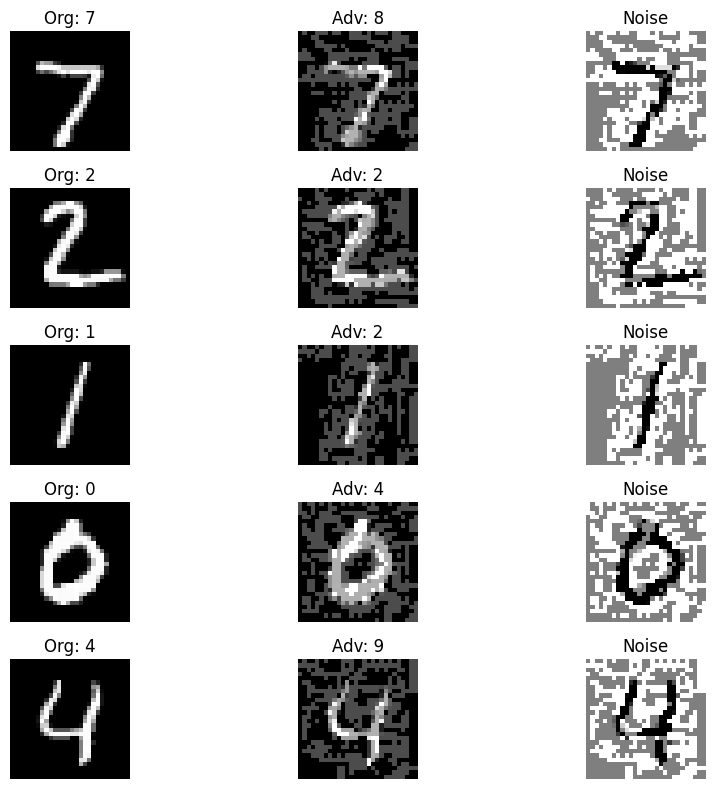


📊 [MNIST] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


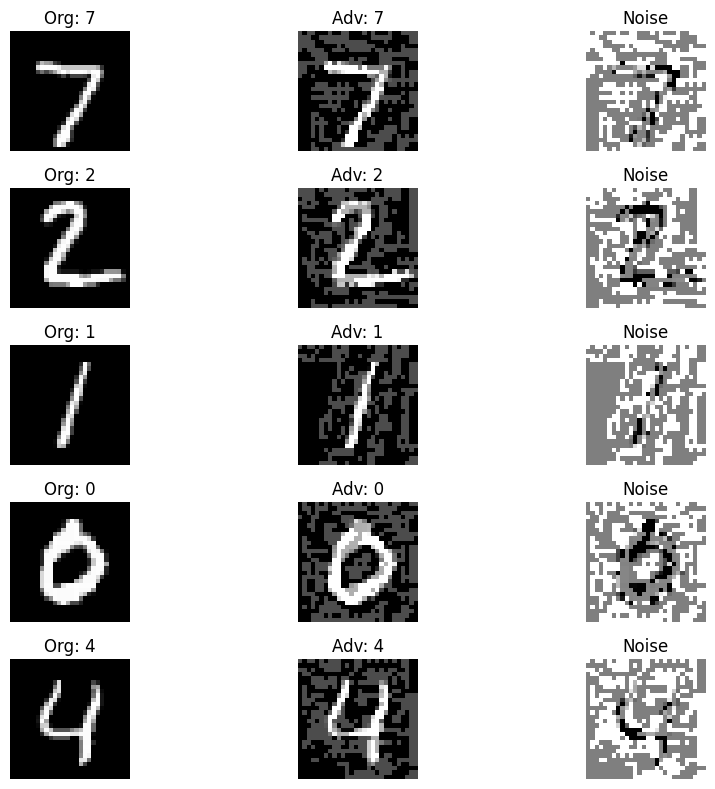


📊 [MNIST] PGD_Targeted 테스트 결과
✅ 공격 성공률: 100.00% (Total: 100 samples)


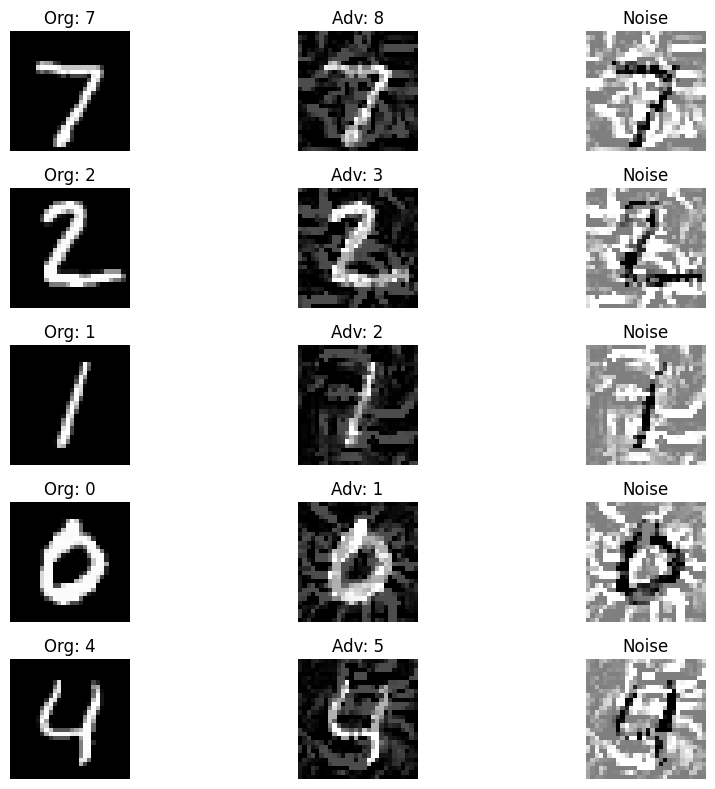


📊 [MNIST] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


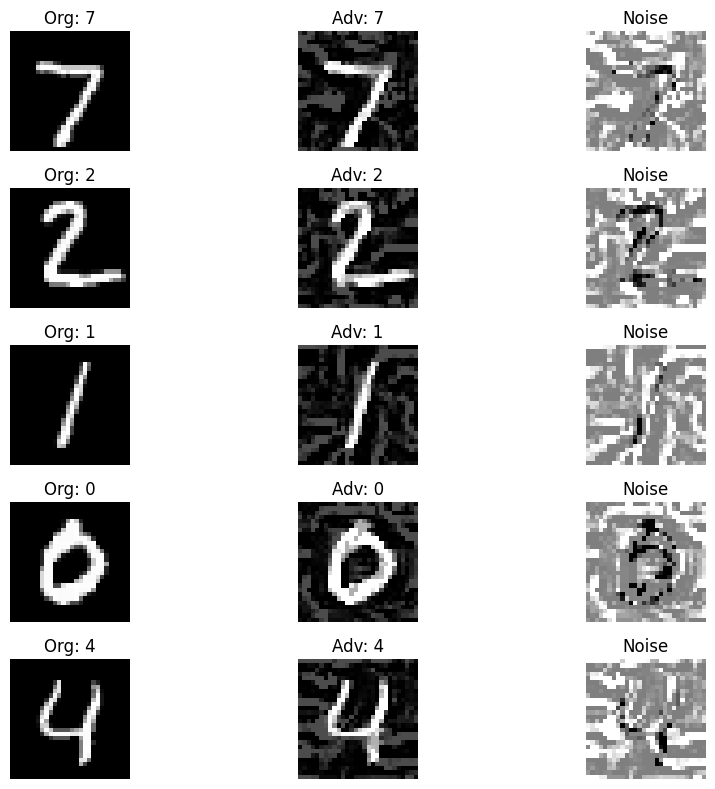

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].



--- CIFAR-10 Attack Evaluation ---


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].



📊 [CIFAR10] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 5.00% (Total: 100 samples)


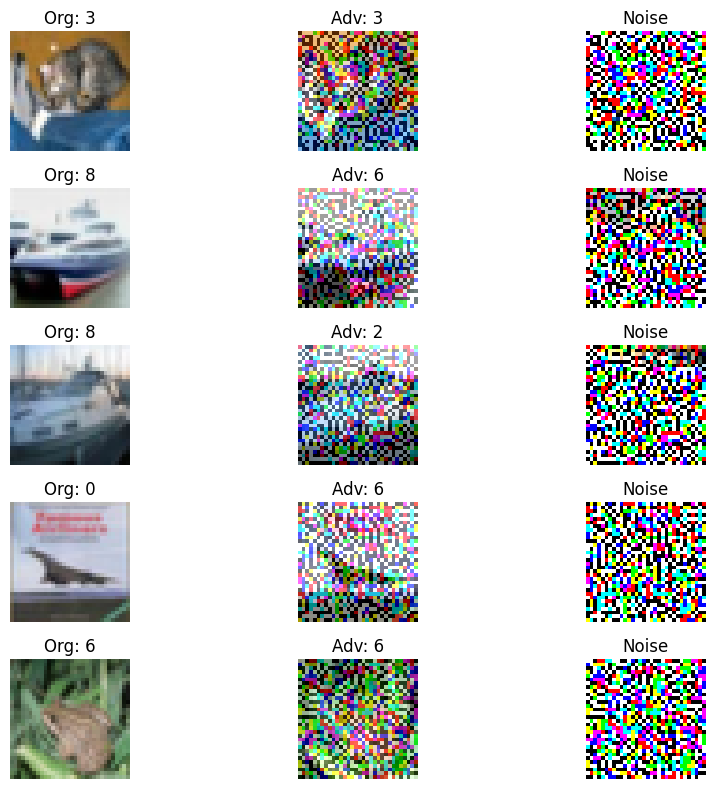

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..3.0000005].



📊 [CIFAR10] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 5.00% (Total: 100 samples)


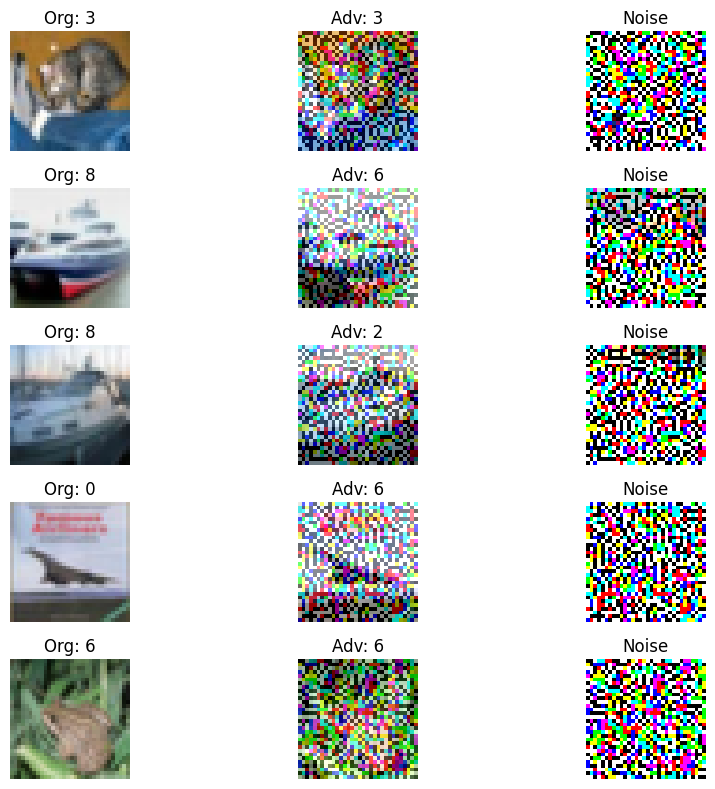

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3999997..1.5999992].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5999985..1.6000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4000005..1.6000006].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7999983..1.7999983].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5999985..1.5999987].



📊 [CIFAR10] PGD_Targeted 테스트 결과
✅ 공격 성공률: 100.00% (Total: 100 samples)


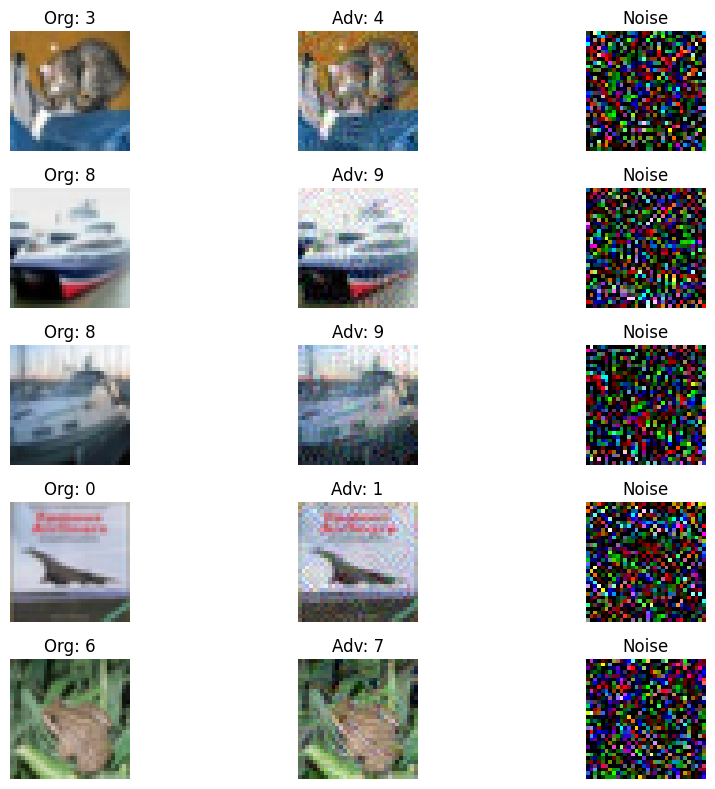

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6000003..1.7999985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9999986..1.9999981].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5999985..1.7999983].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7999992..1.599999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9999987..1.7999983].



📊 [CIFAR10] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


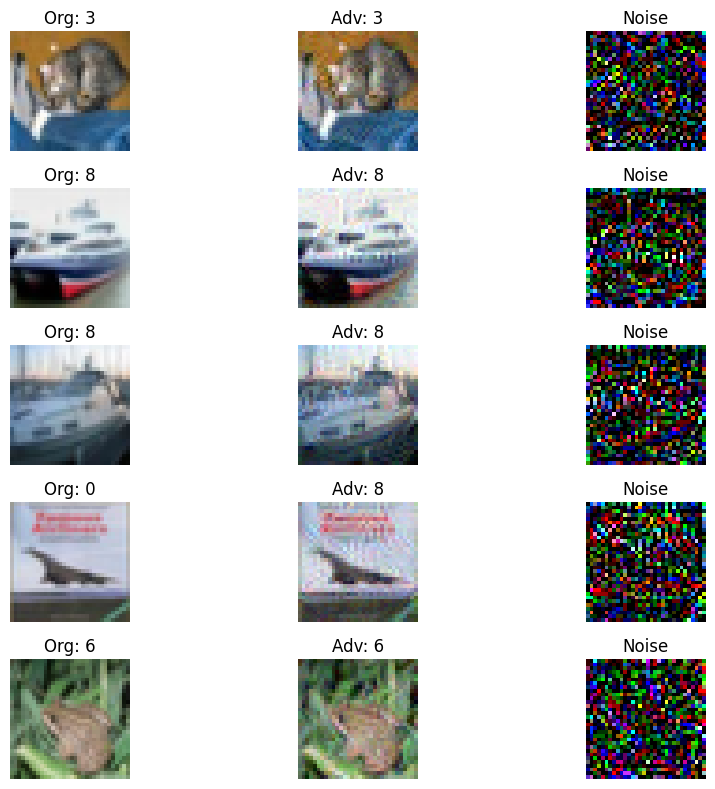

In [22]:
mnist_params = {'eps': 0.3, 'k': 40, 'eps_step': 0.01}
cifar_params = {'eps': 0.3, 'k': 20, 'eps_step': 0.01} 

print("--- MNIST Attack Evaluation ---")
evaluate_attack(mnist_model, device, test_loader, fgsm_targeted, "FGSM_Targeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, fgsm_untargeted, "FGSM_Untargeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, pgd_targeted, "PGD_Targeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])
evaluate_attack(mnist_model, device, test_loader, pgd_untargeted, "PGD_Untargeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])

print("\n--- CIFAR-10 Attack Evaluation ---")
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_targeted, "FGSM_Targeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_untargeted, "FGSM_Untargeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_targeted, "PGD_Targeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_untargeted, "PGD_Untargeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])

--- MNIST Attack Evaluation ---

📊 [MNIST] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 17.00% (Total: 100 samples)


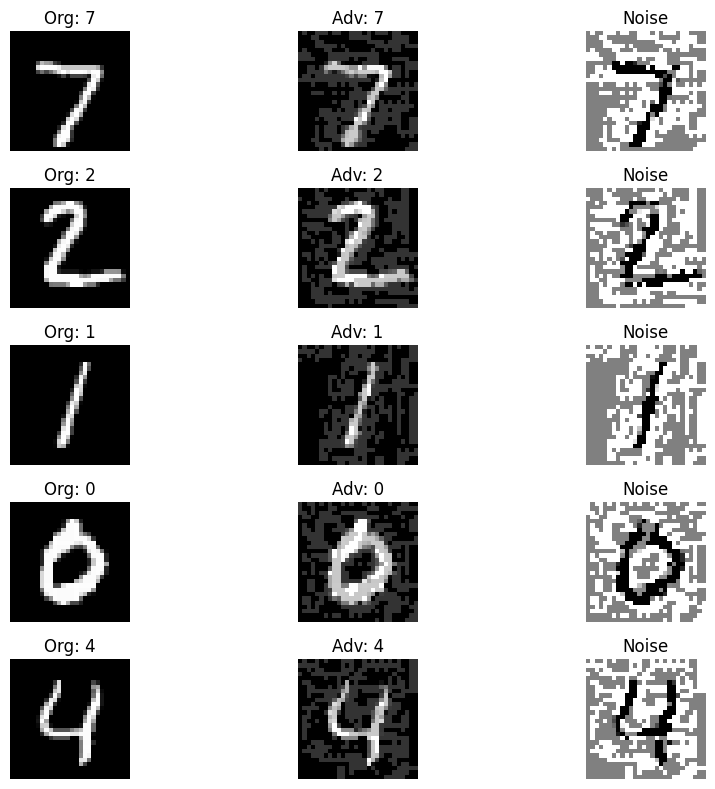


📊 [MNIST] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


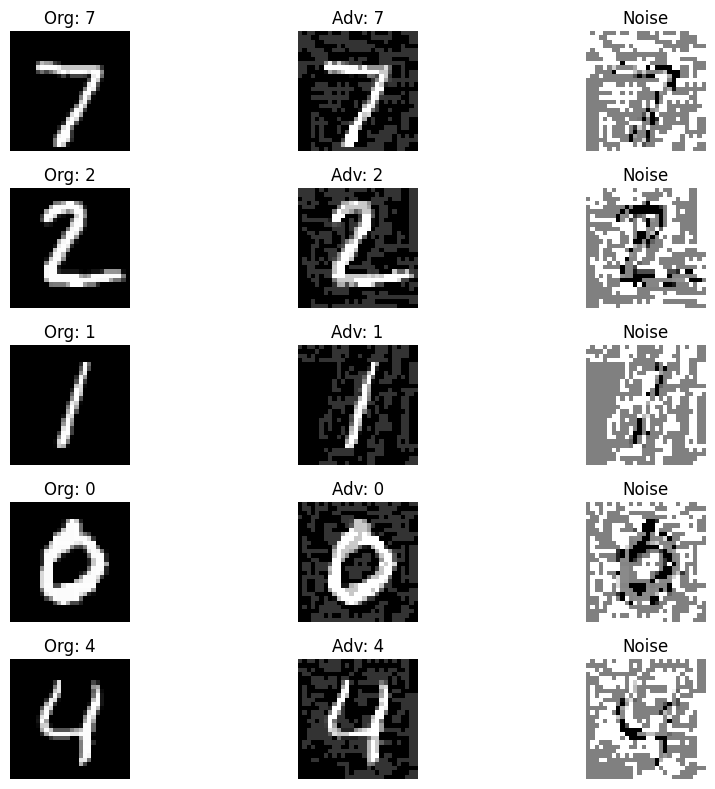


📊 [MNIST] PGD_Targeted 테스트 결과
✅ 공격 성공률: 85.00% (Total: 100 samples)


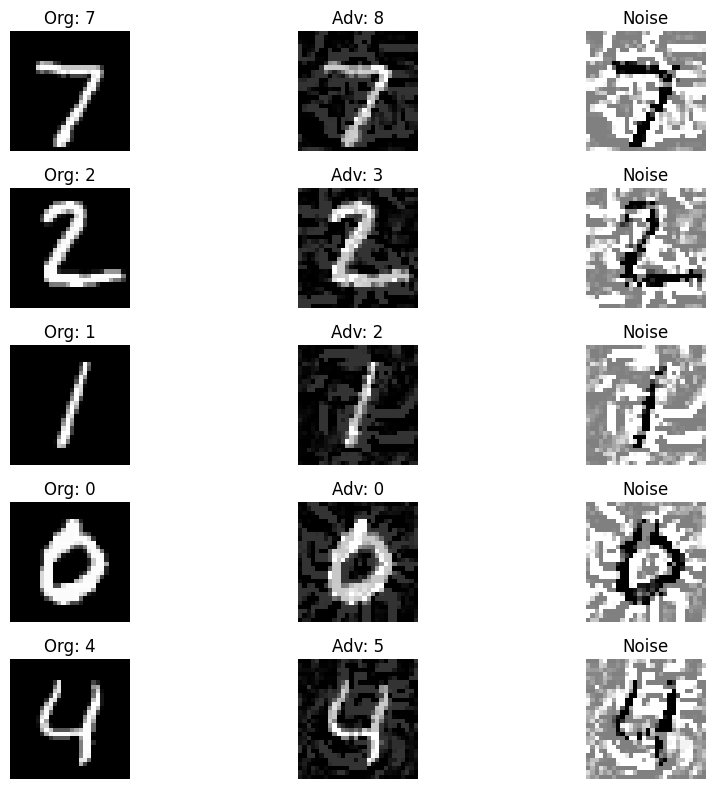


📊 [MNIST] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


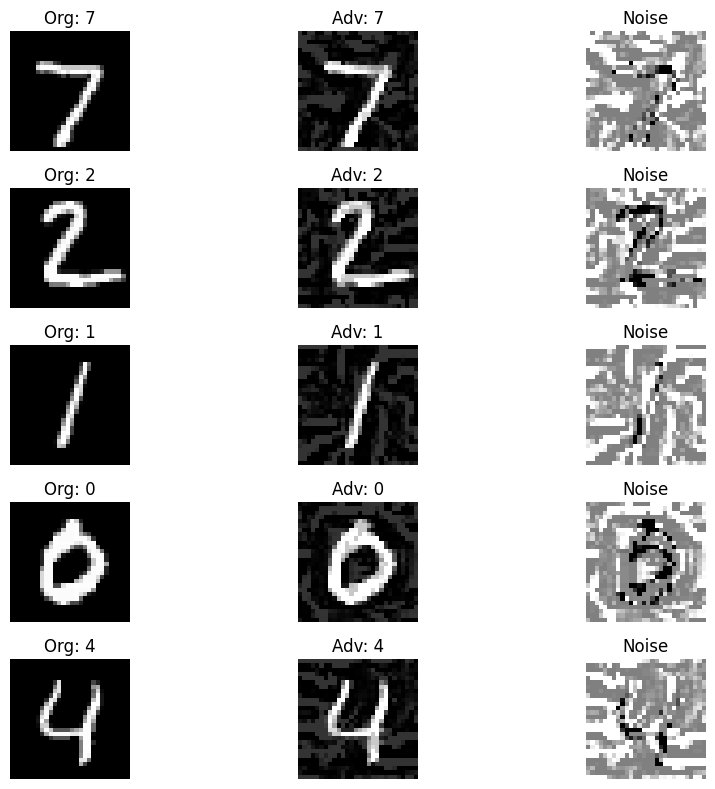

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].



--- CIFAR-10 Attack Evaluation ---

📊 [CIFAR10] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 6.00% (Total: 100 samples)


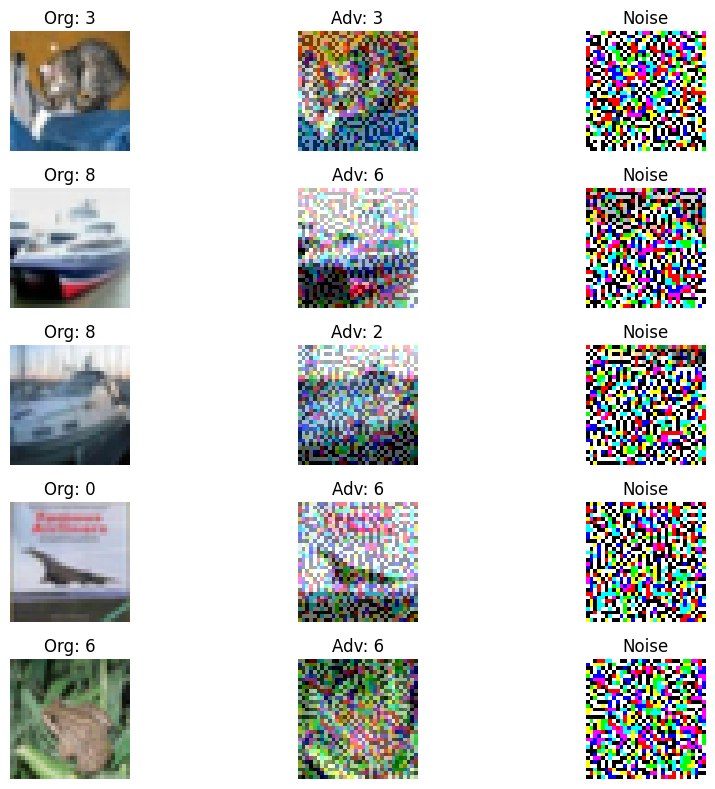

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0000002..2.0000002].



📊 [CIFAR10] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 5.00% (Total: 100 samples)


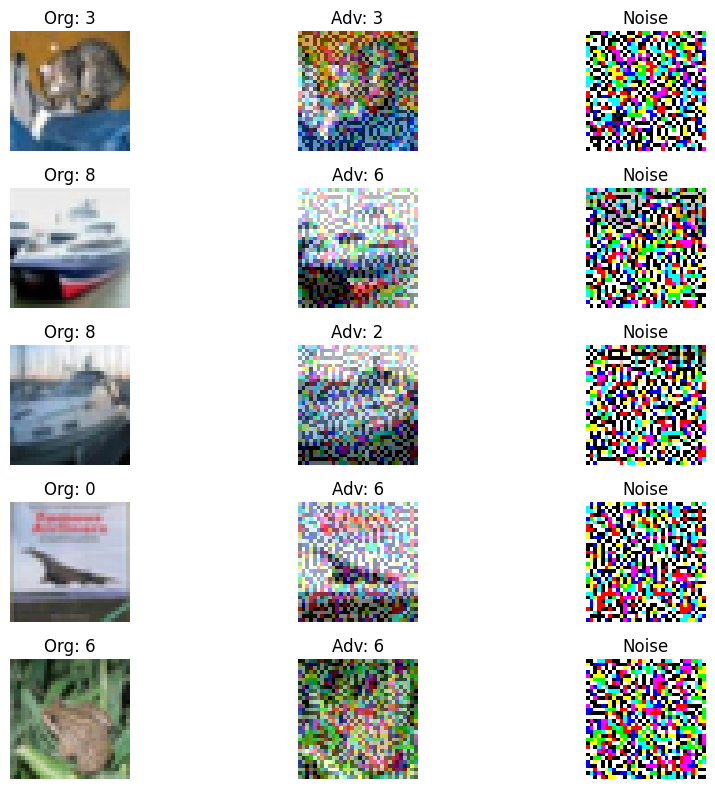

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3999997..1.5999992].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5999985..1.6000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4000005..1.6000006].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7999983..1.7999983].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5999985..1.5999987].



📊 [CIFAR10] PGD_Targeted 테스트 결과
✅ 공격 성공률: 100.00% (Total: 100 samples)


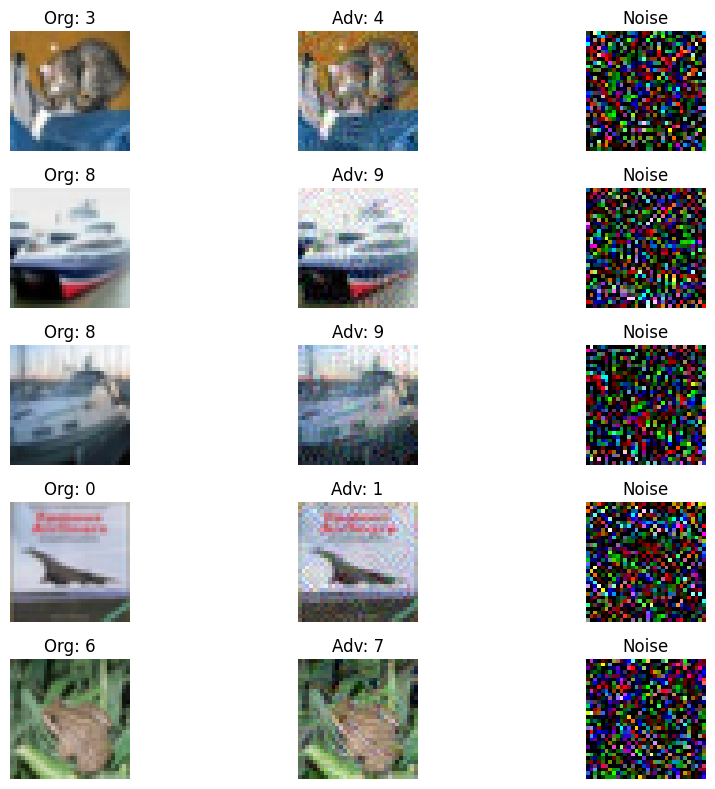

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6000003..1.7999985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9999986..1.9999981].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5999985..1.7999983].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7999992..1.599999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9999987..1.7999983].



📊 [CIFAR10] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


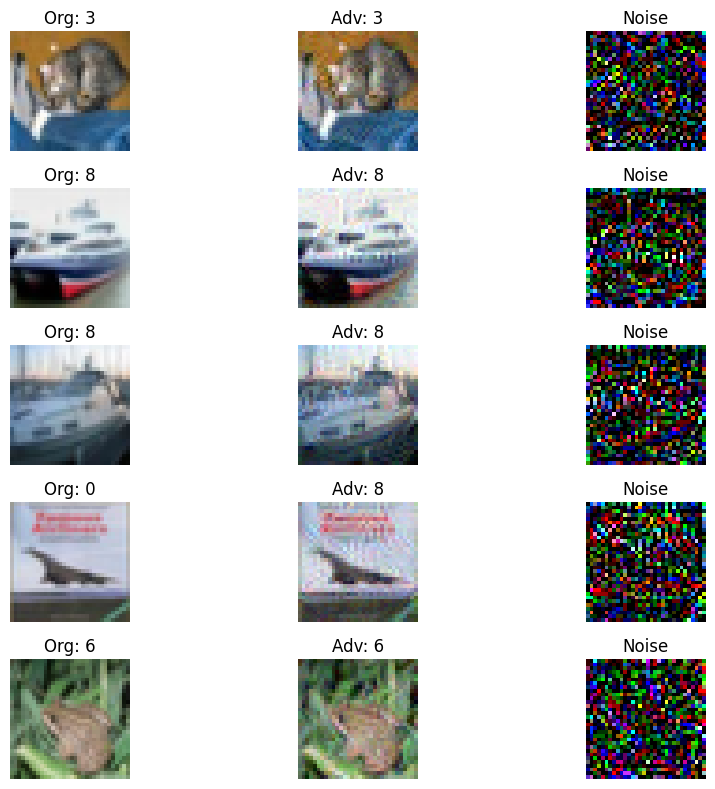

In [23]:
mnist_params = {'eps': 0.2, 'k': 40, 'eps_step': 0.01}
cifar_params = {'eps': 0.2, 'k': 20, 'eps_step': 0.01} 

print("--- MNIST Attack Evaluation ---")
evaluate_attack(mnist_model, device, test_loader, fgsm_targeted, "FGSM_Targeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, fgsm_untargeted, "FGSM_Untargeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, pgd_targeted, "PGD_Targeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])
evaluate_attack(mnist_model, device, test_loader, pgd_untargeted, "PGD_Untargeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])

print("\n--- CIFAR-10 Attack Evaluation ---")
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_targeted, "FGSM_Targeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_untargeted, "FGSM_Untargeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_targeted, "PGD_Targeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_untargeted, "PGD_Untargeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])

--- MNIST Attack Evaluation ---

📊 [MNIST] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 2.00% (Total: 100 samples)


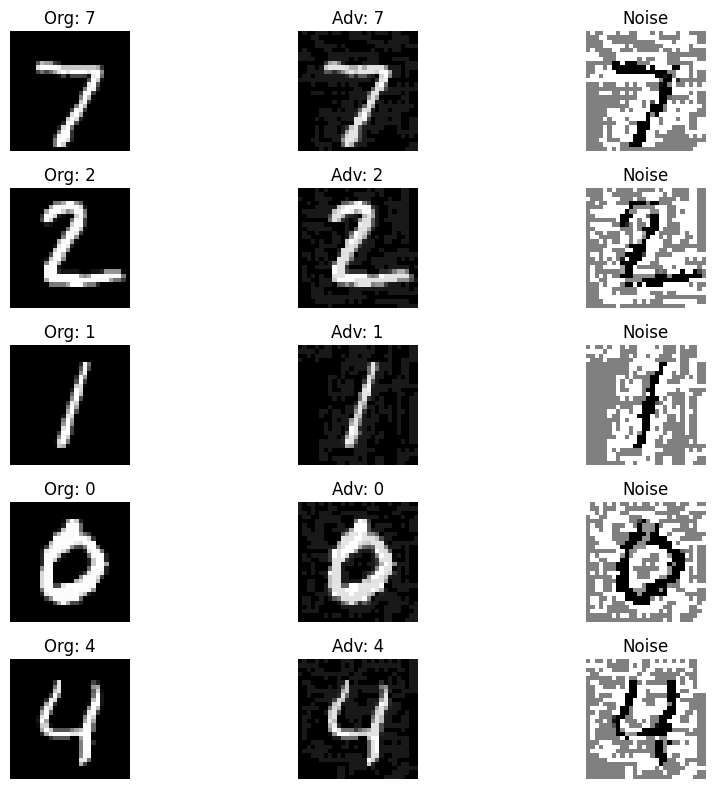


📊 [MNIST] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


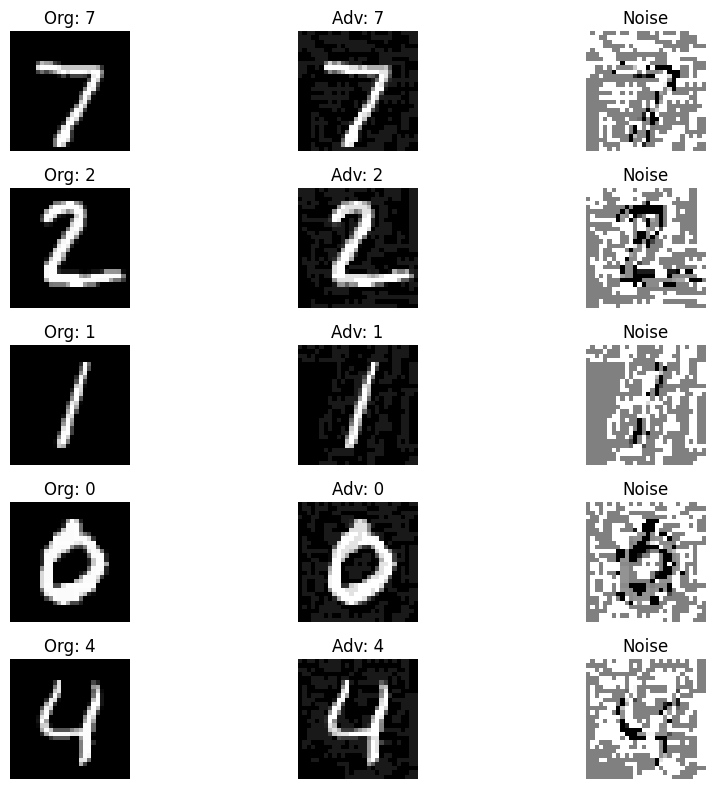


📊 [MNIST] PGD_Targeted 테스트 결과
✅ 공격 성공률: 4.00% (Total: 100 samples)


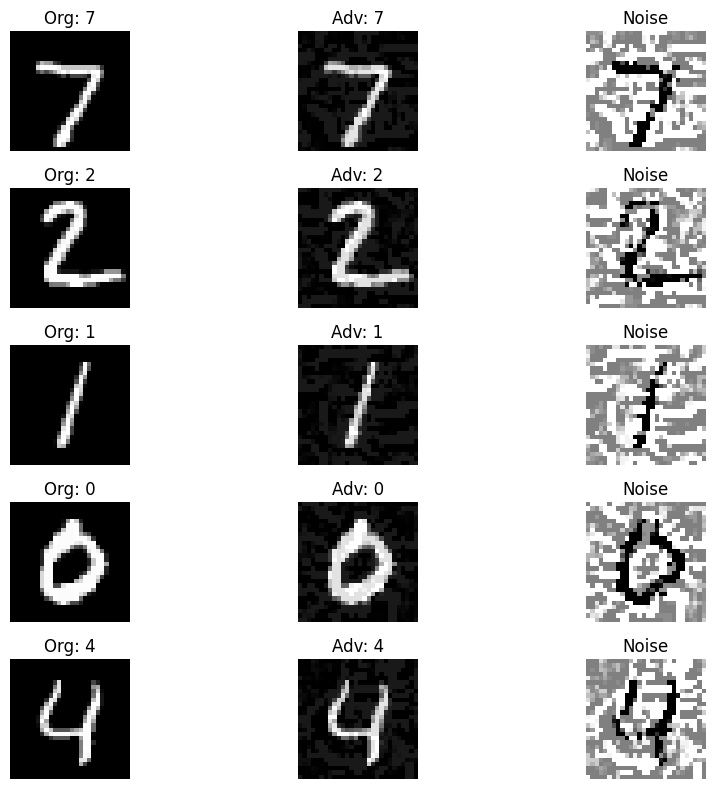


📊 [MNIST] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


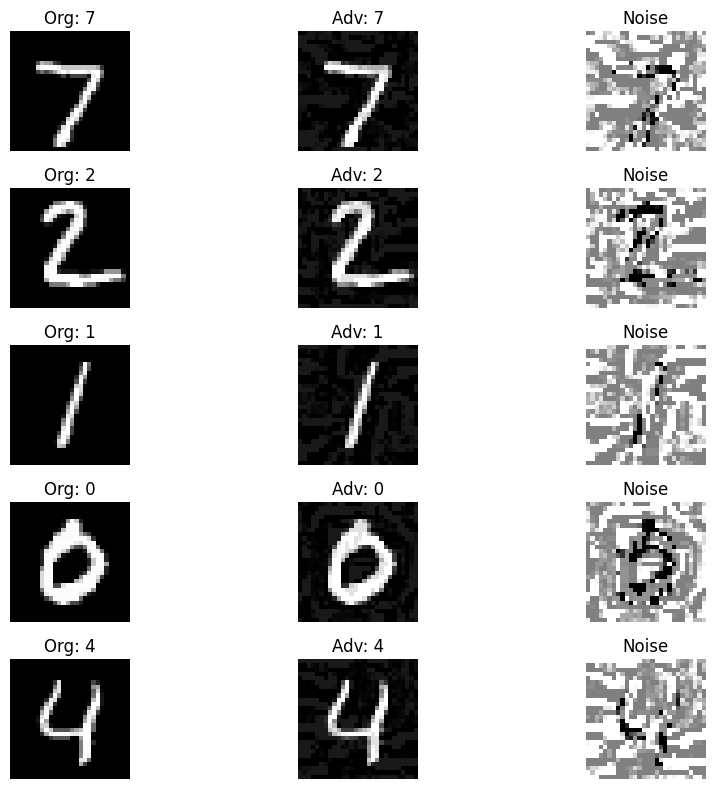

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].



--- CIFAR-10 Attack Evaluation ---

📊 [CIFAR10] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 7.00% (Total: 100 samples)


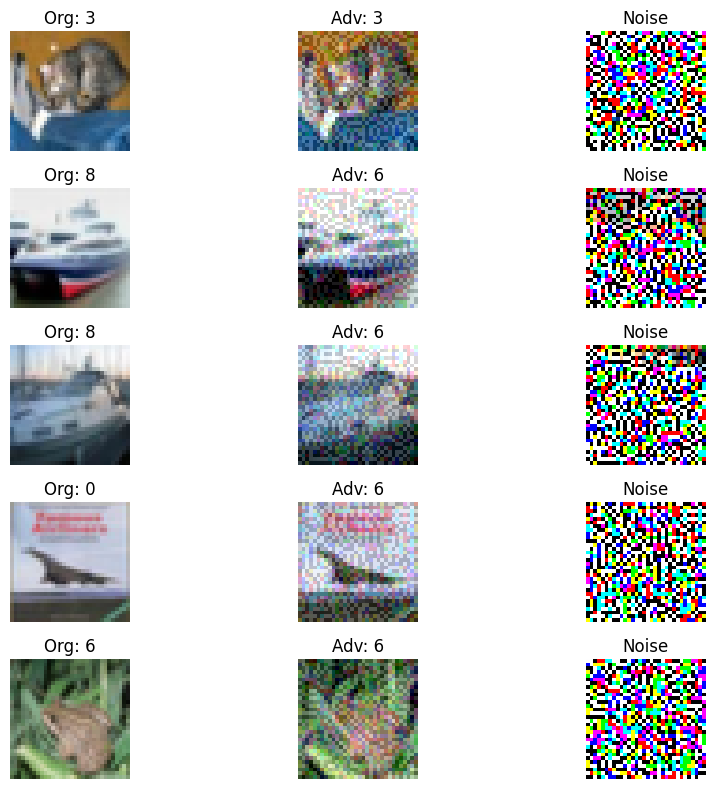

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].



📊 [CIFAR10] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 5.00% (Total: 100 samples)


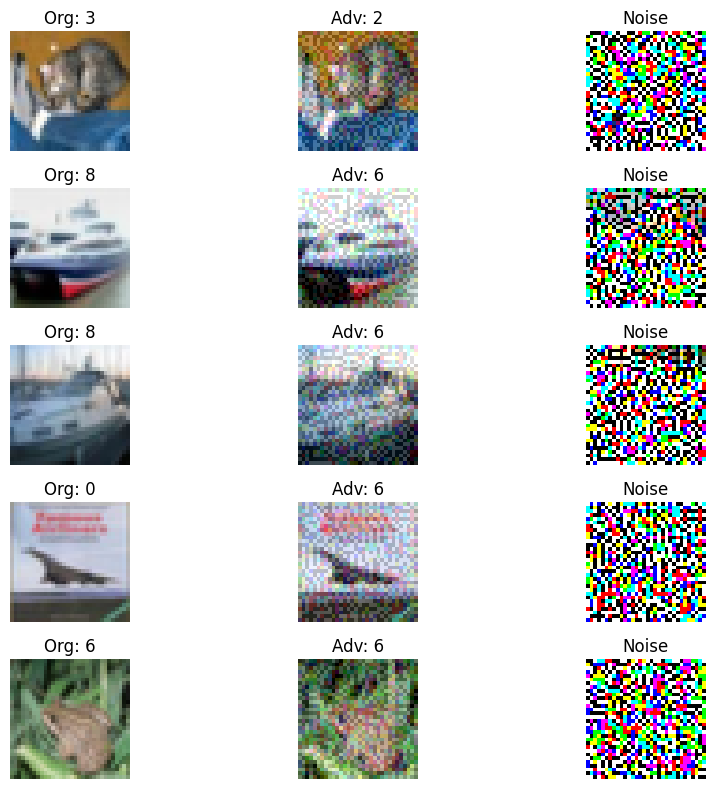

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].



📊 [CIFAR10] PGD_Targeted 테스트 결과
✅ 공격 성공률: 100.00% (Total: 100 samples)


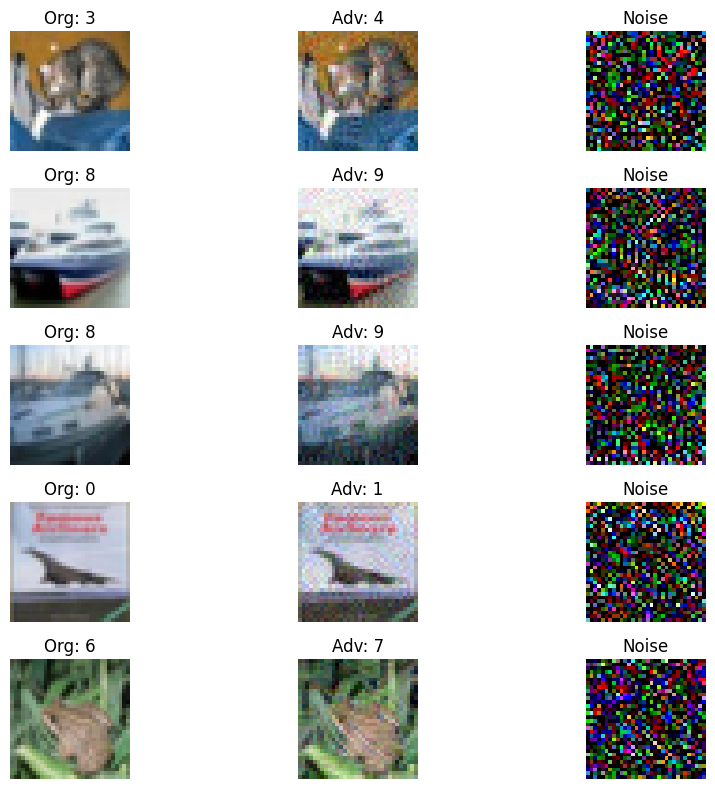

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0000002..1.0000002].



📊 [CIFAR10] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


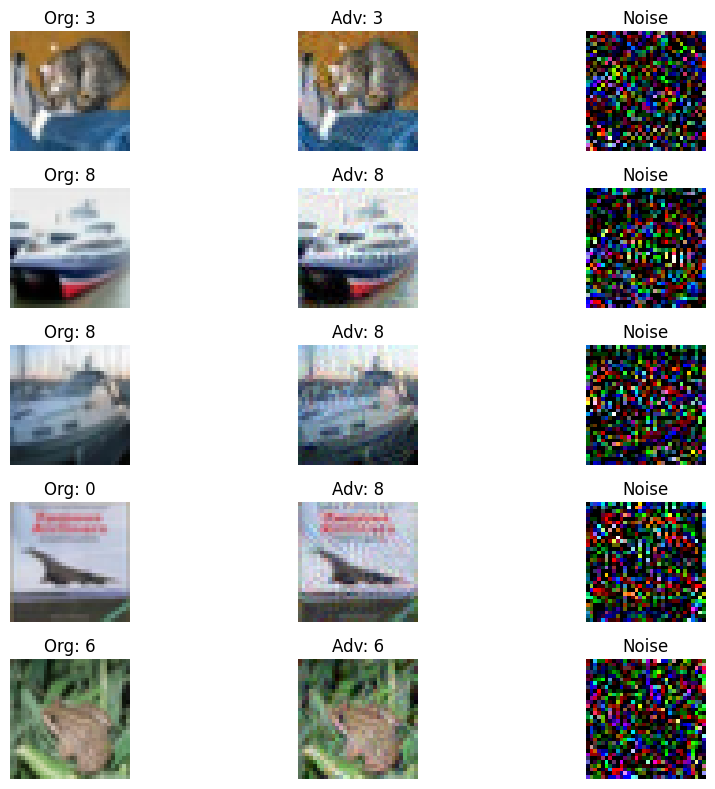

In [24]:
mnist_params = {'eps': 0.1, 'k': 40, 'eps_step': 0.01}
cifar_params = {'eps': 0.1, 'k': 20, 'eps_step': 0.01} 

print("--- MNIST Attack Evaluation ---")
evaluate_attack(mnist_model, device, test_loader, fgsm_targeted, "FGSM_Targeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, fgsm_untargeted, "FGSM_Untargeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, pgd_targeted, "PGD_Targeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])
evaluate_attack(mnist_model, device, test_loader, pgd_untargeted, "PGD_Untargeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])

print("\n--- CIFAR-10 Attack Evaluation ---")
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_targeted, "FGSM_Targeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_untargeted, "FGSM_Untargeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_targeted, "PGD_Targeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_untargeted, "PGD_Untargeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])

--- MNIST Attack Evaluation ---

📊 [MNIST] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 1.00% (Total: 100 samples)


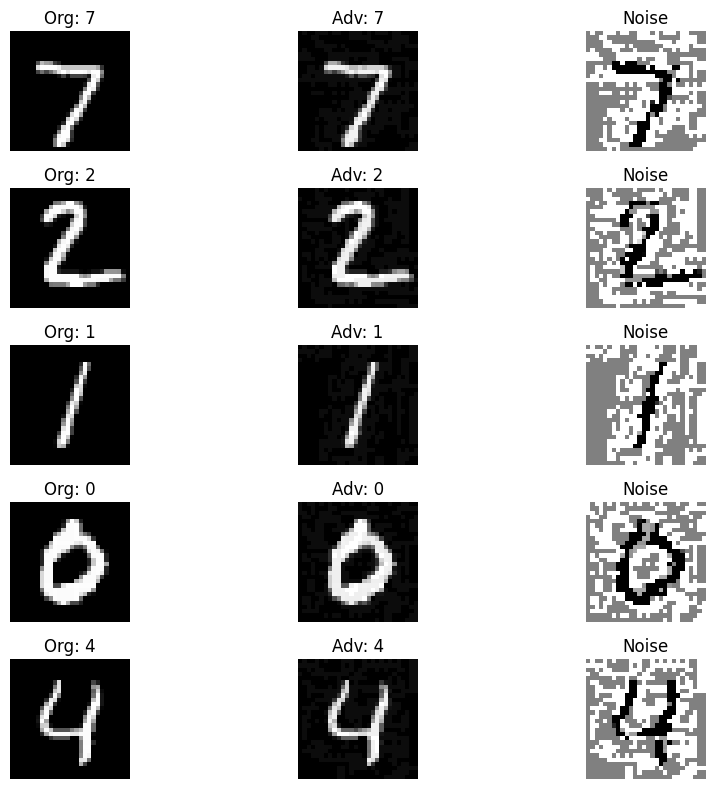


📊 [MNIST] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


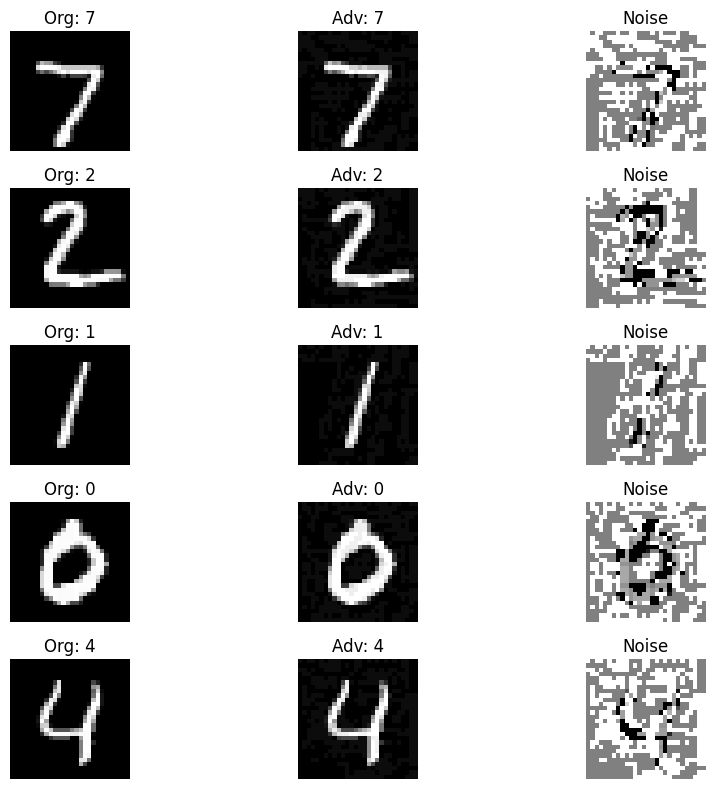


📊 [MNIST] PGD_Targeted 테스트 결과
✅ 공격 성공률: 1.00% (Total: 100 samples)


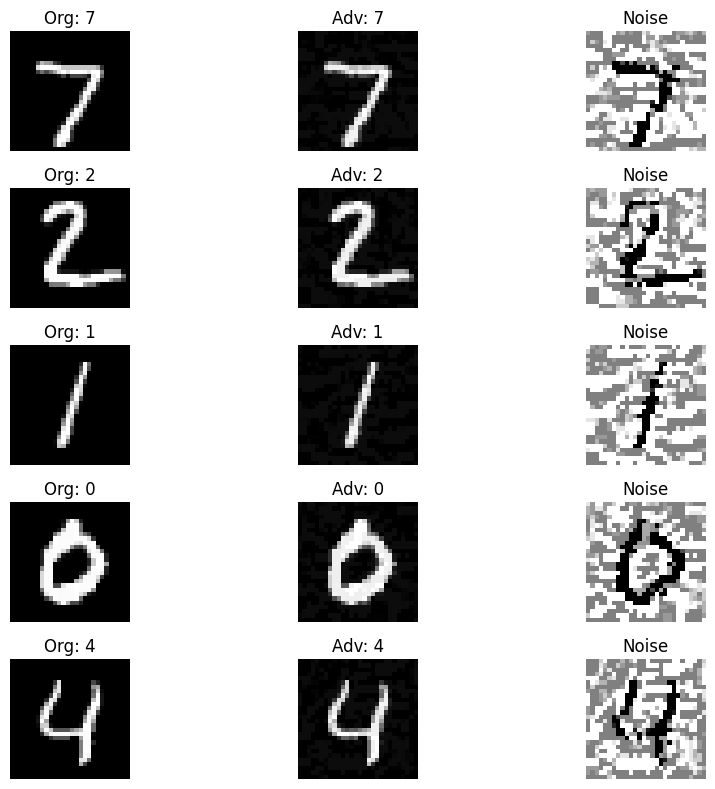


📊 [MNIST] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


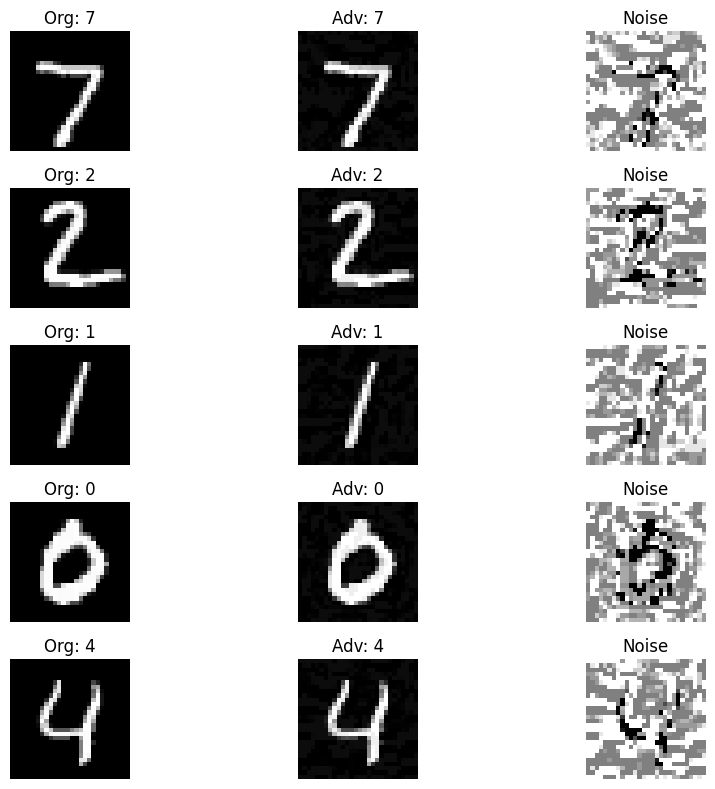

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].



--- CIFAR-10 Attack Evaluation ---

📊 [CIFAR10] FGSM_Targeted 테스트 결과
✅ 공격 성공률: 7.00% (Total: 100 samples)


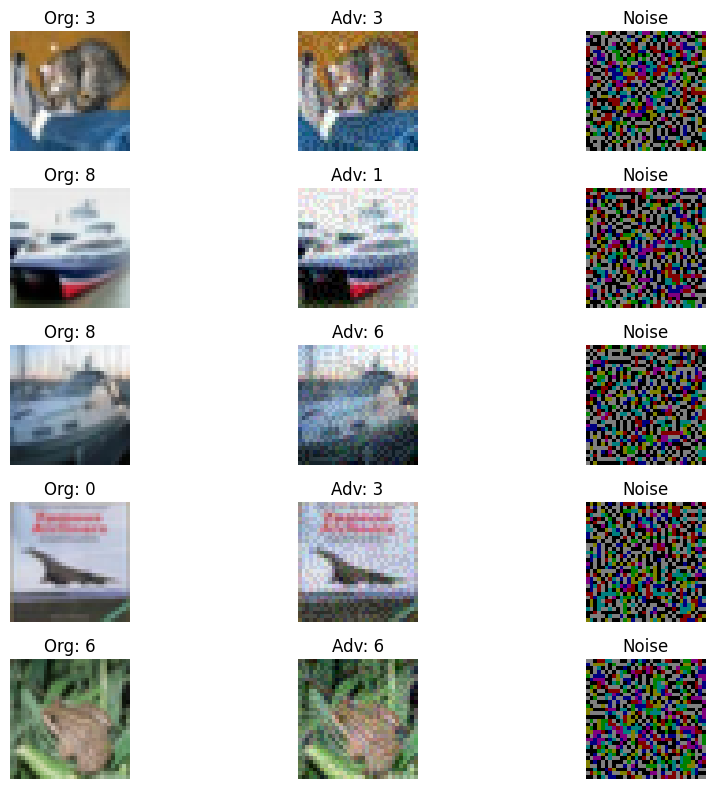

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].



📊 [CIFAR10] FGSM_Untargeted 테스트 결과
✅ 공격 성공률: 1.00% (Total: 100 samples)


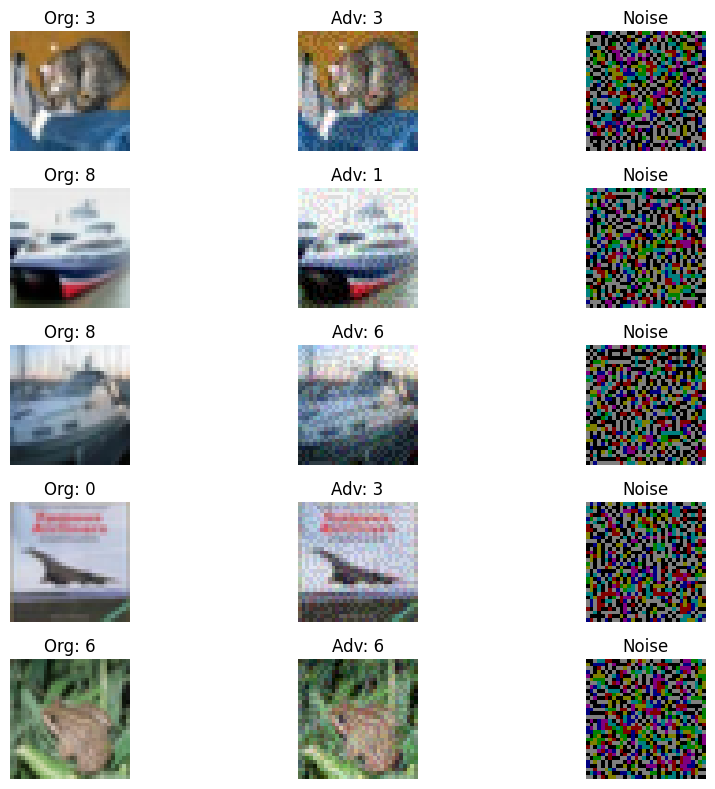

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].



📊 [CIFAR10] PGD_Targeted 테스트 결과
✅ 공격 성공률: 100.00% (Total: 100 samples)


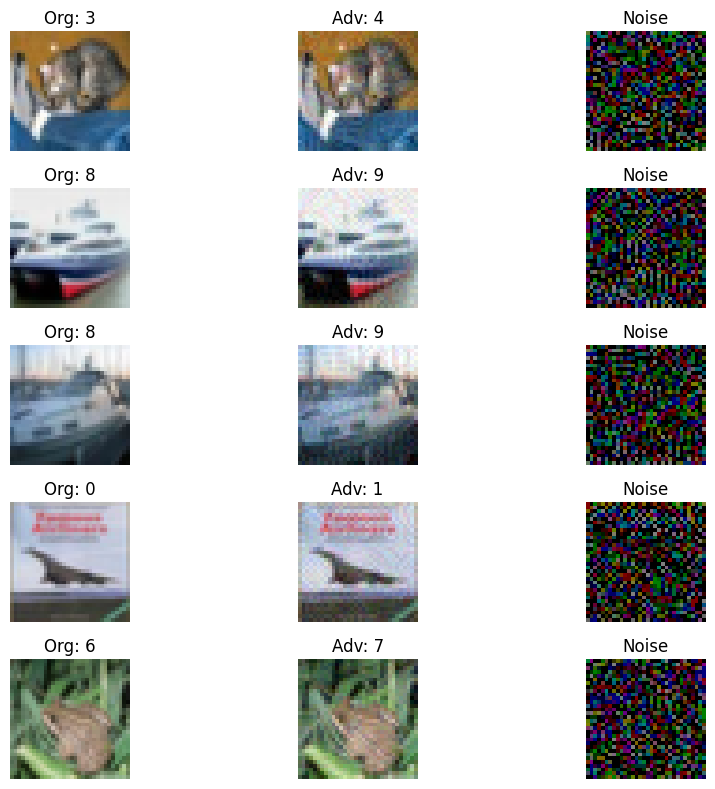

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5000001..0.5000001].



📊 [CIFAR10] PGD_Untargeted 테스트 결과
✅ 공격 성공률: 0.00% (Total: 100 samples)


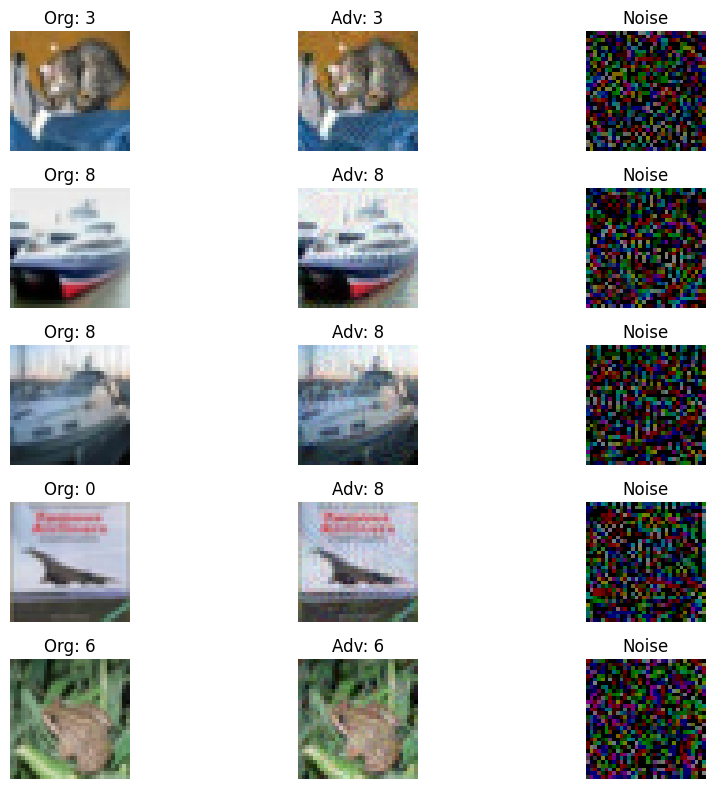

In [25]:
mnist_params = {'eps': 0.05, 'k': 40, 'eps_step': 0.01}
cifar_params = {'eps': 0.05, 'k': 20, 'eps_step': 0.01} 

print("--- MNIST Attack Evaluation ---")
evaluate_attack(mnist_model, device, test_loader, fgsm_targeted, "FGSM_Targeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, fgsm_untargeted, "FGSM_Untargeted", "MNIST", eps=mnist_params['eps'])
evaluate_attack(mnist_model, device, test_loader, pgd_targeted, "PGD_Targeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])
evaluate_attack(mnist_model, device, test_loader, pgd_untargeted, "PGD_Untargeted", "MNIST", k=mnist_params['k'], eps=mnist_params['eps'], eps_step=mnist_params['eps_step'])

print("\n--- CIFAR-10 Attack Evaluation ---")
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_targeted, "FGSM_Targeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, fgsm_untargeted, "FGSM_Untargeted", "CIFAR10", eps=cifar_params['eps'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_targeted, "PGD_Targeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])
evaluate_attack(cifar_model, device, cifar_test_loader, pgd_untargeted, "PGD_Untargeted", "CIFAR10", k=cifar_params['k'], eps=cifar_params['eps'], eps_step=cifar_params['eps_step'])